# Lab 05 — The Reliable-Training Clinic

**One session · 1h30 · guided PyTorch experiment · decisions before syntax**

A six-layer image classifier is training badly. Your job is to diagnose it, change one mechanism at a time, and defend a final training recipe with plots.

> **PyTorch is provided infrastructure today.** Read each supplied block by its purpose, then run it. You are not expected to reproduce its syntax. Tensors, modules, data loaders, and training loops become the subject of the next chapter.

Your work is deliberately small: make predictions, change highlighted configuration values, run controlled experiments, and interpret evidence.

## Session map

| Time | Decision | Evidence |
|---:|---|---|
| 0–10 min | What are we training? | image gallery and class counts |
| 10–25 min | Is the initial signal healthy? | activation scale and signal collapse |
| 25–50 min | Which mechanism repairs training? | aligned train/validation curves |
| 50–65 min | Why do modes matter? | repeated predictions in train/eval |
| 65–80 min | How much dropout? | generalization-gap sweep |
| 80–90 min | What would you deploy? | dashboard and exit ticket |

## 0 — Start the laboratory

The next cell imports the tools, fixes randomness, and defines the visual style. Run it; there is nothing to implement.

In [1]:
from __future__ import annotations

import copy, math, os, random
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms

SEED = 17
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
COLORS = {"fragile": "#ef4444", "he": "#f59e0b", "bn": "#0891b2",
          "dropout": "#7c3aed", "controlled": "#15803d"}

def seed_everything(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

def save_preview(fig, filename):
    target = Path("../assets")
    if target.exists(): fig.savefig(target / filename, dpi=170, bbox_inches="tight")

seed_everything()
sns.set_theme(style="whitegrid", context="notebook")
print(f"PyTorch {torch.__version__} · device = {DEVICE}")

PyTorch 2.13.0+cu130 · device = cpu


### One-minute syntax map

You only need four readings today:

```text
tensor.to(DEVICE)   → put numbers where computation happens
model(images)       → ask the network for predictions
loss.backward()     → compute gradients by backpropagation
optimizer.step()    → update the parameters
```

Treat these as named operations, not syntax to memorize. We will open this black box next week.

## 1 — Meet the evidence

We use Fashion-MNIST: 28×28 grayscale images in ten classes. The supplied cell creates one fixed training/validation split and a smaller session-sized subset so every experiment fits the same 90-minute budget.

In [2]:
DATA_DIR = Path(os.environ.get("COURSE_DATA_DIR", "data"))
transform = transforms.ToTensor()
dataset = datasets.FashionMNIST(DATA_DIR, train=True, download=True, transform=transform)
train_full, val_full = random_split(
    dataset, [50_000, 10_000], generator=torch.Generator().manual_seed(SEED)
)
train_set = Subset(train_full, range(8_000))
val_set = Subset(val_full, range(2_000))

def loaders(batch_size=128):
    train = DataLoader(train_set, batch_size=batch_size, shuffle=True,
                       generator=torch.Generator().manual_seed(SEED), num_workers=0)
    val = DataLoader(val_set, batch_size=256, shuffle=False, num_workers=0)
    return train, val

CLASS_NAMES = dataset.classes
print(f"training examples = {len(train_set):,} · validation examples = {len(val_set):,}")

training examples = 8,000 · validation examples = 2,000


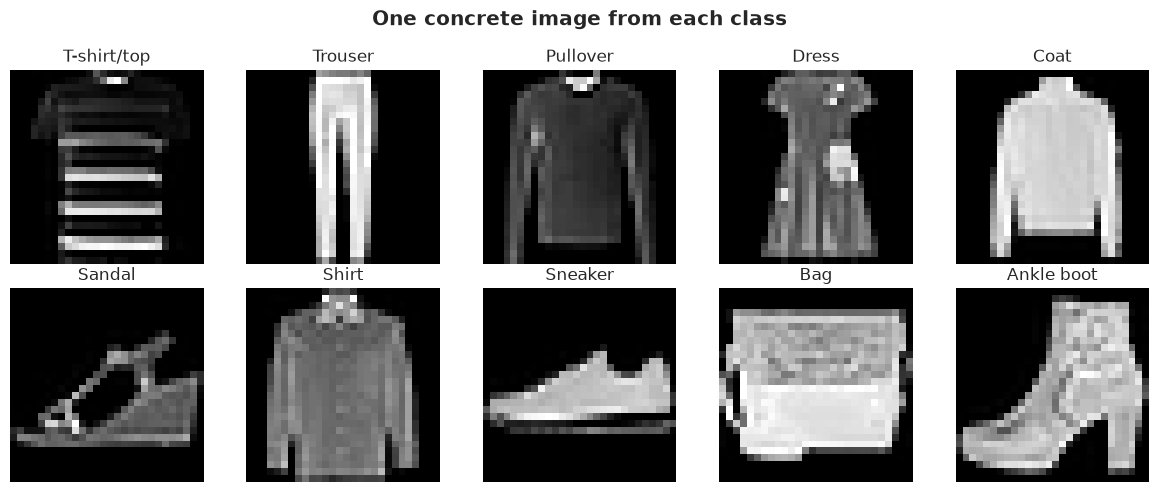

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
seen = set()
for image, target in train_set:
    if target not in seen:
        ax = axes.flat[target]
        ax.imshow(image.squeeze(), cmap="gray")
        ax.set_title(CLASS_NAMES[target]); ax.axis("off"); seen.add(target)
    if len(seen) == 10: break
fig.suptitle("One concrete image from each class", weight="bold")
fig.tight_layout(); save_preview(fig, "fashion-mnist-gallery.png"); plt.show()

### Predict before touching the model

Which two classes do you expect the classifier to confuse most? Write a reason based on visual similarity.

**Prediction:** …

## 2 — Does useful signal survive the first forward pass?

The architecture is fixed: five hidden affine–ReLU blocks and one ten-class output layer. Only the initialization changes.

Before running the diagnostic, rank these choices for a deep ReLU network:

```python
INITIALIZATIONS = ["bad", "xavier", "he"]
```

**Prediction, most stable to least stable:** …

In [4]:
@dataclass(frozen=True)
class Recipe:
    name: str
    init: str
    batch_norm: bool = False
    dropout: float = 0.0
    weight_decay: float = 0.0
    schedule: bool = False
    early_stopping: bool = False

class Classifier(nn.Module):
    def __init__(self, recipe, width=256):
        super().__init__()
        dims = [784, width, width, width, width, width]
        layers = []
        self.relu_layers = []
        for n_in, n_out in zip(dims[:-1], dims[1:]):
            layers.append(nn.Linear(n_in, n_out))
            if recipe.batch_norm: layers.append(nn.BatchNorm1d(n_out))
            relu = nn.ReLU(); layers.append(relu); self.relu_layers.append(relu)
            if recipe.dropout: layers.append(nn.Dropout(recipe.dropout))
        layers.append(nn.Linear(dims[-1], 10))
        self.network = nn.Sequential(*layers)
        self.initialize(recipe.init)

    def initialize(self, method):
        for layer in self.modules():
            if not isinstance(layer, nn.Linear): continue
            if method == "bad": nn.init.normal_(layer.weight, 0, 0.01)
            elif method == "xavier": nn.init.xavier_normal_(layer.weight)
            elif method == "he": nn.init.kaiming_normal_(layer.weight, nonlinearity="relu")
            else: raise ValueError(f"Unknown initialization: {method}")
            nn.init.zeros_(layer.bias)

    def forward(self, images): return self.network(images.flatten(1))

def activation_probe(method):
    seed_everything()
    model = Classifier(Recipe(method, method)).eval()
    images, _ = next(iter(loaders()[1]))
    activations = []
    hooks = [layer.register_forward_hook(
        lambda _m, _i, output: activations.append(output.detach().flatten().numpy())
    ) for layer in model.relu_layers]
    with torch.no_grad(): model(images)
    for hook in hooks: hook.remove()
    return activations

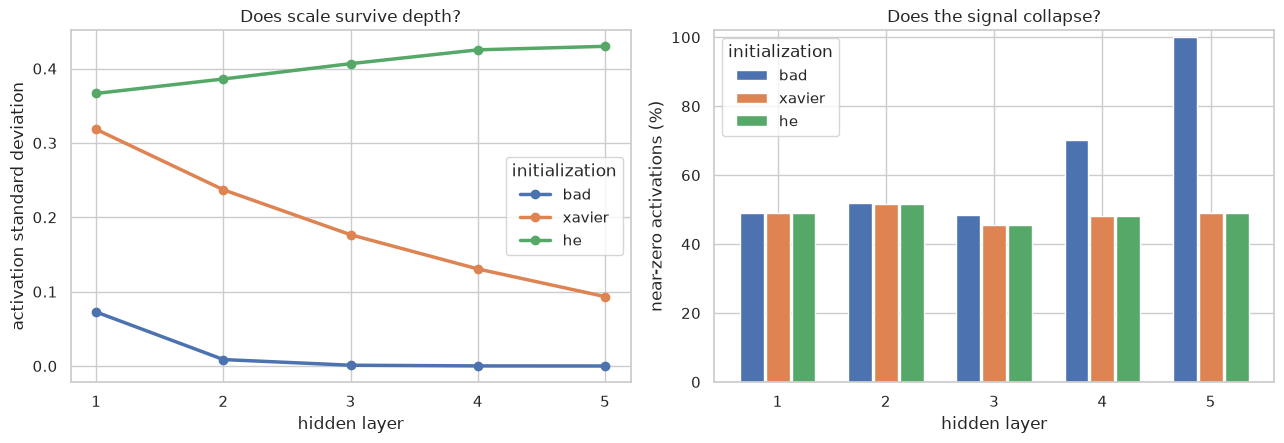

In [5]:
# YOUR DECISION: keep all three for a controlled comparison.
INITIALIZATIONS = ["bad", "xavier", "he"]

activation_data = {method: activation_probe(method) for method in INITIALIZATIONS}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
layers = np.arange(1, 6)
plot_colors = {"bad": "#4c72b0", "xavier": "#dd8452", "he": "#55a868"}
for offset, method in zip((-0.24, 0.0, 0.24), INITIALIZATIONS):
    stds = [values.std() for values in activation_data[method]]
    axes[0].plot(layers, stds, marker="o", lw=2.5,
                 color=plot_colors[method], label=method)
    near_zero = [(np.abs(values) < 1e-4).mean() * 100 for values in activation_data[method]]
    # Side-by-side bars keep Xavier visible even when it is numerically close
    # to He (both naturally send about half their values to zero after ReLU).
    axes[1].bar(layers + offset, near_zero, width=.22,
                color=plot_colors[method], label=method)
axes[0].set(xlabel="hidden layer", ylabel="activation standard deviation",
            title="Does scale survive depth?", xticks=layers)
axes[1].set(xlabel="hidden layer", ylabel="near-zero activations (%)",
            title="Does the signal collapse?", xticks=layers, ylim=(0, 102))
for ax in axes: ax.legend(title="initialization")
fig.tight_layout(); save_preview(fig, "initialization-diagnostics.png"); plt.show()

### Interpret

1. Which curve best preserves a comparable scale through depth?
2. Why does Xavier not exactly target the same variance as He for ReLU?
3. What evidence warns you *before training* that the bad initialization is risky?

## 3 — Repair training one mechanism at a time

Every run receives the same images, seed, architecture width, SGD optimizer, and eight-epoch budget. The labels describe the **only intended changes**.

The long next cell is the training instrument. Read its comments once, then run it. Next week we will rebuild it line by line.

In [6]:
@torch.inference_mode()
def evaluate(model, loader, criterion):
    model.eval()  # BatchNorm running statistics; dropout becomes identity
    loss_sum = correct = count = 0
    for images, targets in loader:
        images, targets = images.to(DEVICE), targets.to(DEVICE)
        logits = model(images); loss = criterion(logits, targets)
        loss_sum += loss.item() * len(targets)
        correct += (logits.argmax(1) == targets).sum().item(); count += len(targets)
    return loss_sum / count, correct / count

def train_recipe(recipe, epochs=8, lr=.05, patience=4):
    seed_everything(); train_loader, val_loader = loaders()
    model = Classifier(recipe).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=.9,
                                weight_decay=recipe.weight_decay)
    scheduler = None
    if recipe.schedule:
        warmup = max(1, min(2, epochs // 4))
        def multiplier(epoch):
            if epoch < warmup: return (epoch + 1) / warmup
            progress = (epoch - warmup) / max(1, epochs - warmup - 1)
            return .05 + .95 * .5 * (1 + math.cos(math.pi * progress))
        scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, multiplier)

    rows, best_loss, best_state, waiting = [], float("inf"), None, 0
    for epoch in range(epochs):
        model.train()  # BatchNorm updates statistics; dropout samples masks
        loss_sum = count = 0
        for images, targets in train_loader:
            images, targets = images.to(DEVICE), targets.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(images), targets)
            if not torch.isfinite(loss): break
            loss.backward(); optimizer.step()
            loss_sum += loss.item() * len(targets); count += len(targets)
        if count == 0: break
        val_loss, val_acc = evaluate(model, val_loader, criterion)
        rows.append(dict(recipe=recipe.name, epoch=epoch+1,
                         train_loss=loss_sum/count, val_loss=val_loss,
                         val_accuracy=val_acc, learning_rate=optimizer.param_groups[0]["lr"]))
        if scheduler: scheduler.step()
        if recipe.early_stopping:
            if val_loss < best_loss - 1e-3:
                best_loss, best_state, waiting = val_loss, copy.deepcopy(model.state_dict()), 0
            else:
                waiting += 1
                if waiting >= patience: break
    if best_state is not None: model.load_state_dict(best_state)
    return model, pd.DataFrame(rows)

def plot_histories(histories, filename=None):
    frame = pd.concat(histories.values(), ignore_index=True)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
    for name, run in frame.groupby("recipe", sort=False):
        axes[0].plot(run.epoch, run.train_loss, marker="o", label=name)
        axes[1].plot(run.epoch, run.val_loss, marker="o", label=name)
    for ax, title in zip(axes, ["Training evidence", "Held-out evidence"]):
        ax.set(xlabel="epoch", ylabel="cross-entropy loss", title=title, yscale="log")
        ax.legend(fontsize=8)
    fig.tight_layout()
    if filename: save_preview(fig, filename)
    plt.show()
    return frame

### Pause — predict the curve order

Which run will have the smoothest first two epochs? Which might have a higher training loss but a lower validation loss?

**Prediction:** …

Training: Fragile baseline


Training: He initialization


Training: He + BatchNorm


Training: He + BN + dropout


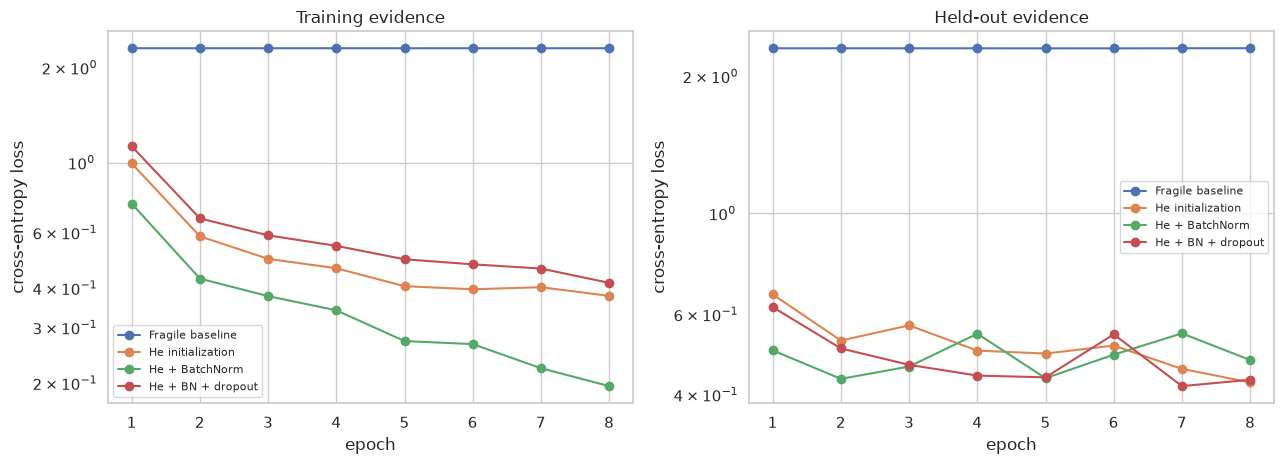

,train_loss,val_loss,val_accuracy
recipe,,,
Fragile baseline,2.303,2.304,0.100
He initialization,0.378,0.426,0.850
He + BatchNorm,0.196,0.477,0.853
He + BN + dropout,0.416,0.431,0.848


In [7]:
# YOUR DECISION: comment out one line only if time is short.
RECIPES = [
    Recipe("Fragile baseline", "bad"),
    Recipe("He initialization", "he"),
    Recipe("He + BatchNorm", "he", batch_norm=True),
    Recipe("He + BN + dropout", "he", batch_norm=True, dropout=.25),
]

models, histories = {}, {}
for recipe in RECIPES:
    print(f"Training: {recipe.name}")
    models[recipe.name], histories[recipe.name] = train_recipe(recipe, epochs=8)

ablation_results = plot_histories(histories, "loss-ablation.png")
ablation_results.groupby("recipe").tail(1)[
    ["recipe", "train_loss", "val_loss", "val_accuracy"]
].set_index("recipe").round(3)

### Diagnose with evidence

Complete these claims with a curve, epoch, or value:

1. The fragile baseline …
2. He initialization changes …
3. BatchNorm changes …
4. Dropout increases/decreases training loss, while validation loss …

Do not call the run with the lowest training loss the winner. Deployment decisions use held-out evidence.

## 4 — One model, two forward behaviors

BatchNorm and dropout both respond to `model.train()` and `model.eval()`, but for different reasons:

- BatchNorm changes which statistics normalize an activation.
- Dropout changes whether a random mask is sampled.

We will send the **same 32 images** through the dropout model repeatedly. Predict the result first.

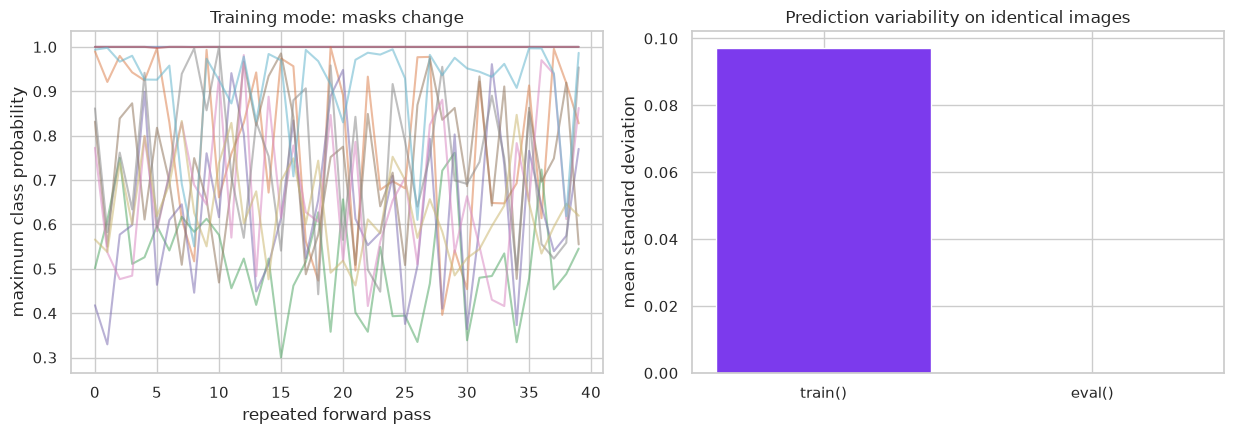

Mean variability in eval mode: 1.9464642e-07


In [8]:
def repeated_confidence(model, images, mode, repeats=40):
    model.train(mode == "train")
    values = []
    with torch.no_grad():
        for _ in range(repeats):
            probabilities = model(images.to(DEVICE)).softmax(1)
            values.append(probabilities.max(1).values.cpu().numpy())
    return np.stack(values)

images, _ = next(iter(loaders()[1])); images = images[:32]
dropout_model = models["He + BN + dropout"]
train_conf = repeated_confidence(dropout_model, images, "train")
eval_conf = repeated_confidence(dropout_model, images, "eval")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))
for index in range(10): axes[0].plot(train_conf[:, index], alpha=.55)
axes[0].set(title="Training mode: masks change", xlabel="repeated forward pass",
            ylabel="maximum class probability")
axes[1].bar(["train()", "eval()"], [train_conf.std(0).mean(), eval_conf.std(0).mean()],
            color=["#7c3aed", "#15803d"])
axes[1].set(title="Prediction variability on identical images",
            ylabel="mean standard deviation")
fig.tight_layout(); save_preview(fig, "train-eval-modes.png"); plt.show()

print("Mean variability in eval mode:", eval_conf.std(0).mean())

### Explain the invariant

1. Why is the evaluation bar approximately zero?
2. Where is the factor $1/q$ applied in PyTorch's inverted dropout?
3. What would be wrong with reporting validation loss while the model remained in training mode?

## 5 — Choose dropout using validation evidence

More regularization is not automatically better. Choose three probabilities to test. Keep `0.0` as the control and avoid `1.0`, which would discard every activation.

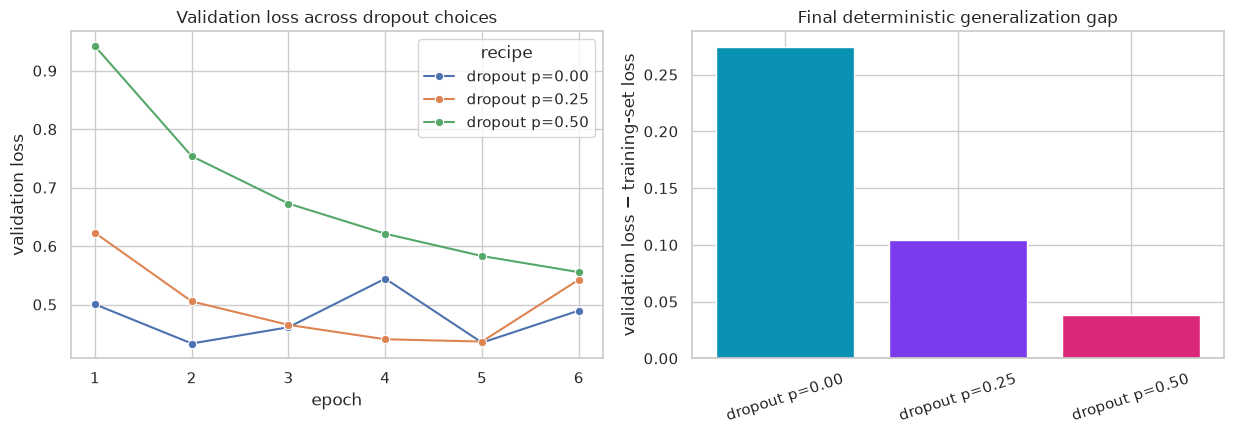

,recipe,train_eval_loss,val_loss,val_accuracy,generalization_gap
5,dropout p=0.00,0.215,0.490,0.836,0.274
11,dropout p=0.25,0.438,0.543,0.802,0.104
17,dropout p=0.50,0.517,0.555,0.793,0.038


In [9]:
# YOUR DECISION: edit these three values, then predict the best validation loss.
DROPOUT_PROBABILITIES = [0.0, 0.25, 0.50]

dropout_runs, dropout_models = {}, {}
train_eval_loader = DataLoader(train_set, batch_size=256, shuffle=False, num_workers=0)
for p in DROPOUT_PROBABILITIES:
    recipe = Recipe(f"dropout p={p:.2f}", "he", batch_norm=True, dropout=p)
    model, dropout_runs[recipe.name] = train_recipe(recipe, epochs=6)
    dropout_models[recipe.name] = model

dropout_frame = pd.concat(dropout_runs.values(), ignore_index=True)
final = dropout_frame.groupby("recipe", sort=False).tail(1).copy()
criterion = nn.CrossEntropyLoss()
final["train_eval_loss"] = [
    evaluate(dropout_models[name], train_eval_loader, criterion)[0] for name in final.recipe
]
final["generalization_gap"] = final.val_loss - final.train_eval_loss

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))
sns.lineplot(data=dropout_frame, x="epoch", y="val_loss", hue="recipe",
             marker="o", ax=axes[0])
axes[0].set(title="Validation loss across dropout choices", ylabel="validation loss")
axes[1].bar(final.recipe, final.generalization_gap, color=["#0891b2", "#7c3aed", "#db2777"])
axes[1].axhline(0, color="black", lw=1)
axes[1].set(title="Final deterministic generalization gap",
            ylabel="validation loss − training-set loss")
axes[1].tick_params(axis="x", rotation=18)
fig.tight_layout(); save_preview(fig, "dropout-sweep.png"); plt.show()
final[["recipe", "train_eval_loss", "val_loss", "val_accuracy", "generalization_gap"]].round(3)

### Make a decision

Select one dropout probability for this run. Support the choice with both training and validation evidence. If two choices are close, prefer the simpler claim: this short experiment may not distinguish them reliably.

**Chosen $p$ and evidence:** …

## 6 — Assemble and inspect the controlled run

The final recipe adds mechanisms that address different problems:

- He initialization and BatchNorm control signal propagation;
- dropout and weight decay regularize the fitted solution;
- warmup and cosine decay control update scale through time;
- early stopping remembers the best validation checkpoint.

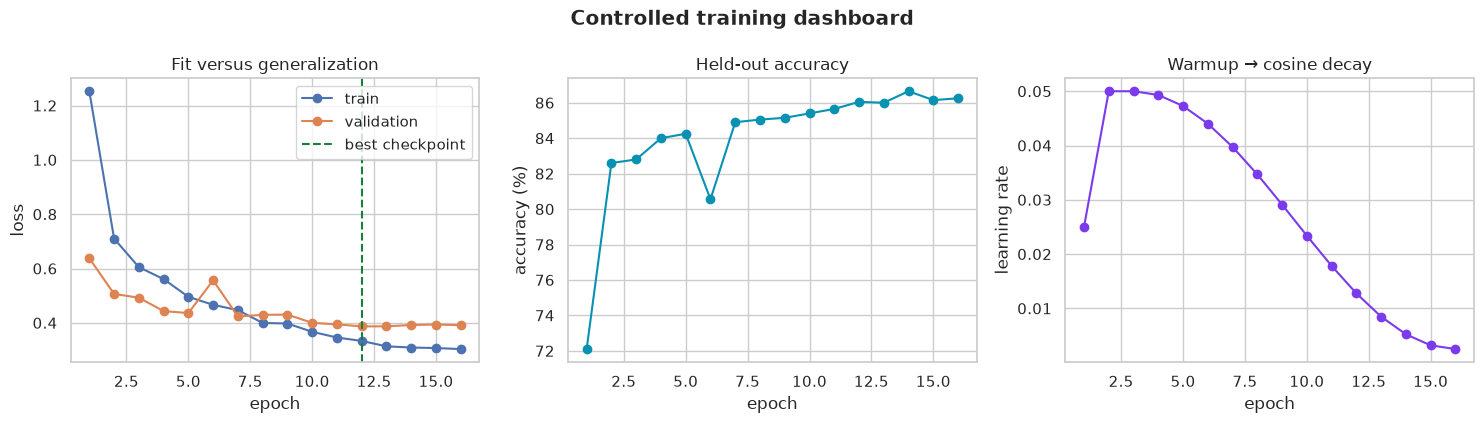

Best checkpoint: epoch 12 · val loss 0.387 · accuracy 86.1%


In [10]:
# YOUR DECISION: use your selected dropout probability.
CHOSEN_DROPOUT = 0.25

controlled = Recipe("Controlled recipe", "he", batch_norm=True,
                    dropout=CHOSEN_DROPOUT, weight_decay=1e-4,
                    schedule=True, early_stopping=True)
controlled_model, controlled_history = train_recipe(controlled, epochs=16, patience=4)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
axes[0].plot(controlled_history.epoch, controlled_history.train_loss, marker="o", label="train")
axes[0].plot(controlled_history.epoch, controlled_history.val_loss, marker="o", label="validation")
best = controlled_history.loc[controlled_history.val_loss.idxmin()]
axes[0].axvline(best.epoch, color="#15803d", ls="--", label="best checkpoint")
axes[0].set(title="Fit versus generalization", xlabel="epoch", ylabel="loss"); axes[0].legend()
axes[1].plot(controlled_history.epoch, controlled_history.val_accuracy * 100,
             marker="o", color="#0891b2")
axes[1].set(title="Held-out accuracy", xlabel="epoch", ylabel="accuracy (%)")
axes[2].plot(controlled_history.epoch, controlled_history.learning_rate,
             marker="o", color="#7c3aed")
axes[2].set(title="Warmup → cosine decay", xlabel="epoch", ylabel="learning rate")
fig.suptitle("Controlled training dashboard", weight="bold")
fig.tight_layout(); save_preview(fig, "controlled-dashboard.png"); plt.show()

print(f"Best checkpoint: epoch {int(best.epoch)} · val loss {best.val_loss:.3f} · "
      f"accuracy {best.val_accuracy:.1%}")

## 7 — Exit ticket

Submit the executed notebook with these answers.

1. Cite one plot showing an initialization problem before training.
2. Which single intervention most changed the first two training epochs?
3. Why can dropout worsen training loss and still help deployment?
4. State the different meanings of `train()` and `eval()` for BatchNorm and dropout.
5. Which checkpoint would you deploy? Cite its epoch and validation evidence.
6. Name one limitation of this comparison (subset size, short horizon, one seed, or another defensible limitation).

**Final rule:** a training technique earns its place through aligned evidence, not because it is fashionable.